In [1]:
#Importamos paquetes
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Directorio de Sol
#os.chdir(r"C:\Users\solsa\OneDrive\Desktop\UdeSA\Cuarto\BigData\GitHub\E337_Grupo2")

#Directorio de Lucas
#os.chdir(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2")

#Directorio de Mateo
os.chdir(r"C:\Users\User\OneDrive\Documentos\GitHub\E337_Grupo2")

In [3]:
## PARTE I: Familiarizandonos con la base EPH

In [4]:
### Ejercicio 2: EPH

In [5]:
# Cargamos las bases

In [6]:
df1 = pd.read_excel('usu_individual_T325.xlsx')

In [7]:
df2 = pd.read_stata('individual_t305.dta', convert_categoricals=False)

In [8]:
### a) Vamos a eliminar los datos que no son de la región de Cuyo y creamos una base unida.

In [9]:
# Homogeneizamos nombres
df2.columns = df2.columns.str.upper()

In [10]:
# Filtramos region de Cuyo (42) en ambas
df1 = df1[df1["REGION"] == 42]
df2 = df2[df2["REGION"] == 42]

In [11]:
# Agregamos variable de año
df1["AÑO"] = 2025
df2["AÑO"] = 2005

In [12]:
# Convertimos las columnas que estan en un formato incorrecto en df2 a numérico.
formato_incorrecto = ['CH14', 'CH15_COD', 'CH16_COD', 'PP04B_COD', 'PP04D_COD', 'PP11B_COD', 'PP11D_COD', 'DECOCUR', 'IDECOCUR', 'RDECOCUR', 'GDECOCUR', 'PDECOCUR', 'ADECOCUR', 'DECINDR', 'IDECINDR', 'RDECINDR', 'GDECINDR', 'PDECINDR', 'ADECINDR', 'DECIFR', 'IDECIFR', 'RDECIFR', 'GDECIFR', 'PDECIFR', 'ADECIFR', 'DECCFR', 'IDECCFR', 'RDECCFR', 'GDECCFR', 'PDECCFR', 'ADECCFR']

In [13]:
# Merge vertical
df = pd.concat([df1, df2], ignore_index=True)

In [14]:
### b) Definimos 15 variables de interes

In [15]:
# Definimos 15 variables de interes
cols_interest = ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 
                'CAT_INAC', 'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H', 'PP07A']

In [16]:
#Primero, vamos a necesitar quedarnos unicamente con las variables de interes que definimos. Veamos primero las columnas que tenemos 

print(df.columns)

Index(['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15',
       'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA',
       ...
       'P_ADECCF', 'AÑO', 'V2_M', 'V5_M', 'V11_M', 'V21_M', 'PJ1_1', 'PJ2_1',
       'PJ3_1', 'IDIMPP'],
      dtype='object', length=244)


In [17]:
# Nos quedamos solo con las columnas de interés (más AÑO para identificar cada período)

def columnas_de_interes(dataframe, cols):
    cols_keep = [col for col in cols if col in dataframe.columns]
    return dataframe[cols_keep]

df = columnas_de_interes(df, cols_interest + ['AÑO']) #Año unicamente está para indicar a que dataframe pertenece cada uno.

In [18]:
#Verificamos que este todo:
df

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH14,CH15_COD,CH16_COD,PP03C,PP04B_COD,PP06H,PP07A,AÑO
0,2.0,9.0,5.0,4.0,1.0,4.0,3.0,139111.11,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2025
1,1.0,2.0,5.0,4.0,7.0,4.0,5.0,139111.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025
2,2.0,38.0,1.0,4.0,1.0,3.0,4.0,139111.11,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2025
3,1.0,39.0,1.0,4.0,4.0,1.0,0.0,139111.11,NaN,NaN,NaN,1.0,4000.0,0.0,0.0,2025
4,1.0,18.0,5.0,4.0,1.0,3.0,3.0,139111.11,98.0,NaN,NaN,NaN,NaN,NaN,NaN,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9259,2.0,23.0,2.0,4.0,3.0,1.0,0.0,125.00,03,,,0.0,9500,0.0,0.0,2005
9260,2.0,7.0,5.0,4.0,1.0,4.0,3.0,125.00,01,,,0.0,,0.0,0.0,2005
9261,1.0,5.0,5.0,4.0,7.0,4.0,5.0,125.00,00,,,0.0,,0.0,0.0,2005
9262,1.0,2.0,5.0,4.0,7.0,4.0,5.0,125.00,,,,0.0,,0.0,0.0,2005


In [19]:
# Ahora nos queda comprovar de que efectivamente los datos están en el mismo formato en cada dataframe
# Separamos nuevamente por año para comparar
df_2005 = df[df['AÑO'] == 2005]
df_2025 = df[df['AÑO'] == 2025]

# Revisamos tipo de dato y valores únicos por variable para cada año
for col in cols_interest:
    print(f"\n{'='*50}")
    print(f"Variable: {col}")
    print(f"  Tipo 2005: {df_2005[col].dtype} | Tipo 2025: {df_2025[col].dtype}")
    print(f"  Valores únicos 2005: {sorted(df_2005[col].dropna().unique())}")
    print(f"  Valores únicos 2025: {sorted(df_2025[col].dropna().unique())}")




Variable: CH04
  Tipo 2005: float64 | Tipo 2025: float64
  Valores únicos 2005: [np.float64(1.0), np.float64(2.0)]
  Valores únicos 2025: [np.float64(1.0), np.float64(2.0)]

Variable: CH06
  Tipo 2005: float64 | Tipo 2025: float64
  Valores únicos 2005: [np.float64(-1.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0

In [20]:
#Con esto podemos ver cada caso cuales son los formatos en que se están guardando las cosas. 

#Respecto al tipo de dato parece que no tenemos problema alguno, al menos analizándolo de esta forma
#Ahora bien, respecto a los valores únicos tanto para 2005 como 2025, podemos observar que para algunas variables tenemos inconsistencias.

#Luego, para CH14, en 2005 estos están guardados como strings, mientras que en 2025 fueron guardados como números
#Para CH15_COD y CH16_COD 2005 tiene strings con ceros adelante y 2025 tiene floats.
#Por último, PP04B_COD tiene en 2005 strings en sus datos mientras que 2025 tiene floats también. 

In [21]:
# CH14: 2005 es string con ceros adelante → convertir a numérico
df['CH14'] = pd.to_numeric(df['CH14'], errors='coerce')

# CH15_COD y CH16_COD: mismo problema que CH14
df['CH15_COD'] = pd.to_numeric(df['CH15_COD'], errors='coerce')
df['CH16_COD'] = pd.to_numeric(df['CH16_COD'], errors='coerce')

# PP04B_COD: 2005 es string → convertir a numérico
df['PP04B_COD'] = pd.to_numeric(df['PP04B_COD'], errors='coerce')

# Verificamos que quedó todo bien
for col in cols_interest:
    print(f"{col}: {df[col].dtype}")

CH04: float64
CH06: float64
CH07: float64
CH08: float64
NIVEL_ED: float64
ESTADO: float64
CAT_INAC: float64
IPCF: float64
CH14: float64
CH15_COD: float64
CH16_COD: float64
PP03C: float64
PP04B_COD: float64
PP06H: float64
PP07A: float64


In [22]:
### c) Realizamos las correciones necesarias

In [23]:
#Hay que revisar cada variable y buscar valores que no tengan sentido y no concuerden con lo que nos dice los diccionarios
#Para CH06, tenemos que al principio empieza con -1.0, cosa que no tiene sentido para la edad.
#Por otro lado, IPCF tiene dentro de ella el valor de -9, cosa que de vuelta no tiene sentido al ser "Monto de ingreso per cápita familiar"
#Según nuestro diccionario de 2025, los códigos 9, 99, 999, 9999 significan que son Non Values para empezar.
#El código 0 suele significar “no corresponde a la secuencia”.
#Entonces, tanto para CH08, CH14, PP07A y IPCF podemos ver que les está pasando esto. Por lo tanto hay que corregir esto.  

In [24]:
# CH06: edad -1 no tiene sentido → NaN
df['CH06'] = df['CH06'].replace(-1, np.nan)

# CH08: 9 = Non Value
df['CH08'] = df['CH08'].replace(9, np.nan)

# CH14: 99 = Non Value
df['CH14'] = df['CH14'].replace(99, np.nan)

# PP07A: 9 = Non Value
df['PP07A'] = df['PP07A'].replace(9, np.nan)

# IPCF: -9 = no respuesta según diccionario
df['IPCF'] = df['IPCF'].replace(-9, np.nan)

In [25]:
#Miremos la base de datos corregida y veamos que todo este en orden:
df

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH14,CH15_COD,CH16_COD,PP03C,PP04B_COD,PP06H,PP07A,AÑO
0,2.0,9.0,5.0,4.0,1.0,4.0,3.0,139111.11,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2025
1,1.0,2.0,5.0,4.0,7.0,4.0,5.0,139111.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025
2,2.0,38.0,1.0,4.0,1.0,3.0,4.0,139111.11,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2025
3,1.0,39.0,1.0,4.0,4.0,1.0,0.0,139111.11,NaN,NaN,NaN,1.0,4000.0,0.0,0.0,2025
4,1.0,18.0,5.0,4.0,1.0,3.0,3.0,139111.11,98.0,NaN,NaN,NaN,NaN,NaN,NaN,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9259,2.0,23.0,2.0,4.0,3.0,1.0,0.0,125.00,3.0,NaN,NaN,0.0,9500.0,0.0,0.0,2005
9260,2.0,7.0,5.0,4.0,1.0,4.0,3.0,125.00,1.0,NaN,NaN,0.0,NaN,0.0,0.0,2005
9261,1.0,5.0,5.0,4.0,7.0,4.0,5.0,125.00,0.0,NaN,NaN,0.0,NaN,0.0,0.0,2005
9262,1.0,2.0,5.0,4.0,7.0,4.0,5.0,125.00,NaN,NaN,NaN,0.0,NaN,0.0,0.0,2005


In [26]:
### d) Figura de heatmap:

#Primero realicemos el gráfico que se nos está pidiendo

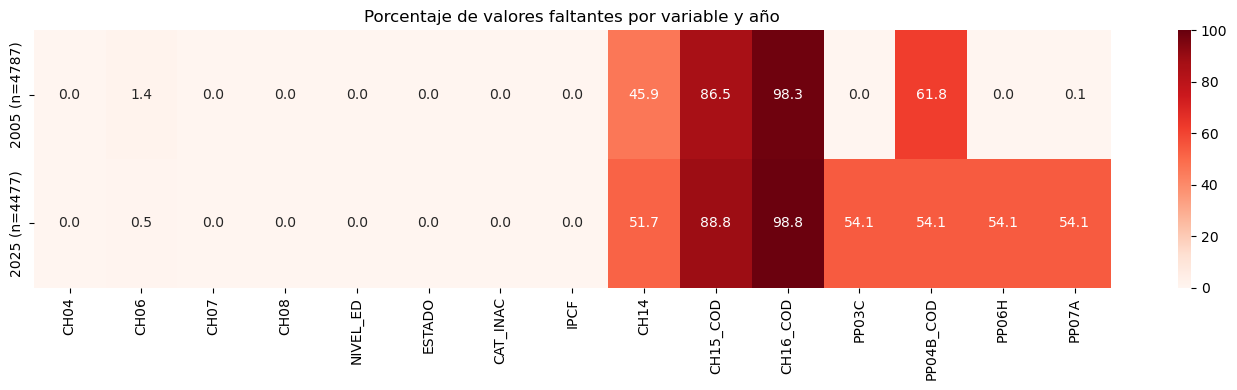

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos el porcentaje de faltantes por variable y por año
missing_2005 = df[df['AÑO'] == 2005][cols_interest].isnull().mean() * 100
missing_2025 = df[df['AÑO'] == 2025][cols_interest].isnull().mean() * 100

# Cantidad de observaciones por año
n_2005 = len(df[df['AÑO'] == 2005])
n_2025 = len(df[df['AÑO'] == 2025])

# Armamos un DataFrame para el heatmap
missing_df = pd.DataFrame({
    f'2005 (n={n_2005})': missing_2005,
    f'2025 (n={n_2025})': missing_2025
}).T

# Graficamos
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(missing_df, 
            annot=True,        # muestra el porcentaje en cada celda
            fmt='.1f',         # un decimal
            cmap='Reds',       # escala de rojos: más oscuro = más faltantes
            vmin=0, vmax=100,
            ax=ax)

ax.set_title('Porcentaje de valores faltantes por variable y año')
plt.tight_layout()
plt.show()

In [28]:
# Podemos observar que para las variables de CH15_COD y CH16_COD estás presentan altos porcentajes de NonValues dentro de ellas tanto para 2005 como para 2025
# Mientras que para ls variables CH14 y PP04B_COD, estas dos presetan entre un 45 y 60% de datos NonValues para los años 2025 y 2005.
# Para las variables PP03C, PP06H y PP07A estas presentan un alto porcentaje para los años de 2025, siendo que solamente en 2005 para PP07A tenemos un 1% de NonValues.

In [29]:
## PARTE II: Primer Análisis Exploratorio

In [30]:
### Ejercicio 3: Gráfico de barras

In [31]:
#Nos piden que contruyamos una gráfico de barras para la composición por sexo de 2005 y 2025 en nuestra región, es decir la de Cuyo.

CH04
2.0    52.726133
1.0    47.273867
Name: proportion, dtype: float64
CH04
2.0    53.249944
1.0    46.750056
Name: proportion, dtype: float64


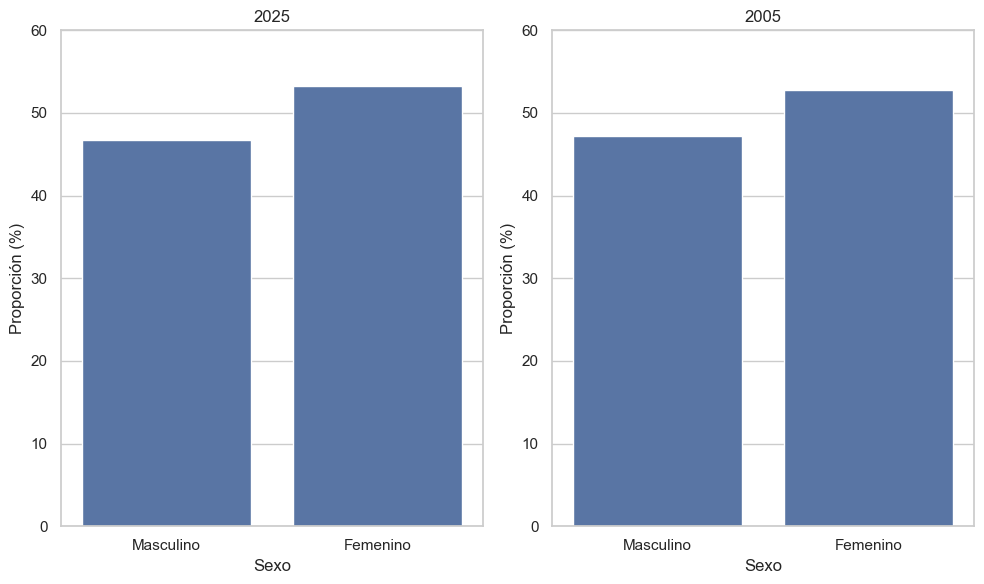

In [32]:
#Primero guardemos en variables apartes las proporciones ya hechas para 2025 y 2005:

# 2005
sexo_2005 = df_2005['CH04'].value_counts(normalize=True) * 100 #normalize es para que efectivamente nos de proporciones en vez de recuentos normales.
print(sexo_2005)

# 2025
sexo_2025 = df_2025['CH04'].value_counts(normalize=True) * 100
print(sexo_2025)


# Extraemos en el orden correcto
# Asumiendo CH04: 1 = Masculino, 2 = Femenino
valores_2005 = [sexo_2005.get(1.0, 0), sexo_2005.get(2.0, 0)]
valores_2025 = [sexo_2025.get(1.0, 0), sexo_2025.get(2.0, 0)]

labels = ['Masculino', 'Femenino']

sns.set(style="whitegrid")

# Crear figura con dos subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

# Gráfico 2025
sns.barplot(x=labels, y=valores_2025, ax=axs[0])
axs[0].set_title("2025")
axs[0].set_ylim(0, 60)
axs[0].set_ylabel("Proporción (%)")
axs[0].set_xlabel("Sexo")

# Gráfico 2005
sns.barplot(x=labels, y=valores_2005, ax=axs[1])
axs[1].set_title("2005")
axs[1].set_ylim(0, 60)
axs[1].set_ylabel("Proporción (%)")
axs[1].set_xlabel("Sexo")

plt.tight_layout()
plt.show()

In [33]:
# Tanto para 2005 como para 2025, las proporciones entre masculino y feminino se mantienen bastante parecidas, es decir 
# que para masculino ronda entre 52% y 53% tanto para 2025 como para 2005 y para femenino entre 46% y 47%.

In [34]:
### Ejercicio 4: Matriz de correlación

In [35]:
# Primero, identifiquemos que variables necesitan ser dummies para el gráfico

print('\nInfo:\n', df['CH04'].info)
print('\nInfo:\n', df['CH07'].info)
print('\nInfo:\n', df['CH08'].info)
print('\nInfo:\n', df['NIVEL_ED'].info)
print('\nInfo:\n', df['ESTADO'].info)
print('\nInfo:\n', df['CAT_INAC'].info)
print('\nInfo:\n', df['IPCF'].info)


Info:
 <bound method Series.info of 0       2.0
1       1.0
2       2.0
3       1.0
4       1.0
       ... 
9259    2.0
9260    2.0
9261    1.0
9262    1.0
9263    2.0
Name: CH04, Length: 9264, dtype: float64>

Info:
 <bound method Series.info of 0       5.0
1       5.0
2       1.0
3       1.0
4       5.0
       ... 
9259    2.0
9260    5.0
9261    5.0
9262    5.0
9263    4.0
Name: CH07, Length: 9264, dtype: float64>

Info:
 <bound method Series.info of 0       4.0
1       4.0
2       4.0
3       4.0
4       4.0
       ... 
9259    4.0
9260    4.0
9261    4.0
9262    4.0
9263    1.0
Name: CH08, Length: 9264, dtype: float64>

Info:
 <bound method Series.info of 0       1.0
1       7.0
2       1.0
3       4.0
4       1.0
       ... 
9259    3.0
9260    1.0
9261    7.0
9262    7.0
9263    2.0
Name: NIVEL_ED, Length: 9264, dtype: float64>

Info:
 <bound method Series.info of 0       4.0
1       4.0
2       3.0
3       1.0
4       3.0
       ... 
9259    1.0
9260    4.0
9261    4.0
9262   

In [36]:
# Primero, sabemos también por el diccionario que CH04 va a tener que ser una variable dummy, ya que nos indica si es hombre o mujer la persona
# Lo mismo le pasa a las variables CH07, CH08, NIVEL_ED, ESTADO, CAT_INAC 
# El único que no tiene problemas es IPCF

In [37]:
# Creemos entonces las variables dummies para cada caso en forma de dataframe

In [38]:
# 1) CH04, CH07, CH08, NIVEL_ED, ESTADO, CAT_INAC 

In [39]:
dummies = []

df_ch04 = df['CH04'].astype('string')
dummies.append(pd.get_dummies(df_ch04, prefix='CH04'))

#Ahora, nos falta para las otras categorias

df_ch07 = df['CH07'].astype('string')
dummies.append(pd.get_dummies(df_ch07, prefix='CH07'))

df_ch08 = df['CH08'].astype('string')
dummies.append(pd.get_dummies(df_ch08, prefix='CH08'))

df_nivel = df['NIVEL_ED'].astype('string')
dummies.append(pd.get_dummies(df_nivel, prefix='NIVEL_ED'))

df_estado = df['ESTADO'].astype('string')
dummies.append(pd.get_dummies(df_estado, prefix='ESTADO'))

df_cat = df['CAT_INAC'].astype('string')
dummies.append(pd.get_dummies(df_cat, prefix='CAT_INAC'))

# Por último, agregemos la única variable no categorica que tenemos, que viene a ser IPCF

dummies.append(df[['IPCF']])

# unimos todo en un solo DataFrame
dummies = pd.concat(dummies, axis=1)

dummies.head()


,CH04_1.0,CH04_2.0,CH07_1.0,CH07_2.0,CH07_3.0,CH07_4.0,CH07_5.0,CH08_1.0,CH08_12.0,CH08_2.0,...,ESTADO_4.0,CAT_INAC_0.0,CAT_INAC_1.0,CAT_INAC_2.0,CAT_INAC_3.0,CAT_INAC_4.0,CAT_INAC_5.0,CAT_INAC_6.0,CAT_INAC_7.0,IPCF
0,False,True,False,False,False,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,139111.11
1,True,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,139111.11
2,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,139111.11
3,True,False,True,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,139111.11
4,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,139111.11


In [40]:
dummies.columns

Index(['CH04_1.0', 'CH04_2.0', 'CH07_1.0', 'CH07_2.0', 'CH07_3.0', 'CH07_4.0',
       'CH07_5.0', 'CH08_1.0', 'CH08_12.0', 'CH08_2.0', 'CH08_23.0',
       'CH08_3.0', 'CH08_4.0', 'NIVEL_ED_1.0', 'NIVEL_ED_2.0', 'NIVEL_ED_3.0',
       'NIVEL_ED_4.0', 'NIVEL_ED_5.0', 'NIVEL_ED_6.0', 'NIVEL_ED_7.0',
       'ESTADO_0.0', 'ESTADO_1.0', 'ESTADO_2.0', 'ESTADO_3.0', 'ESTADO_4.0',
       'CAT_INAC_0.0', 'CAT_INAC_1.0', 'CAT_INAC_2.0', 'CAT_INAC_3.0',
       'CAT_INAC_4.0', 'CAT_INAC_5.0', 'CAT_INAC_6.0', 'CAT_INAC_7.0', 'IPCF'],
      dtype='object')

In [41]:
dummies['CAT_INAC_0.0']

0       False
1       False
2       False
3        True
4       False
        ...  
9259     True
9260    False
9261    False
9262    False
9263    False
Name: CAT_INAC_0.0, Length: 9264, dtype: boolean

In [42]:
# Cambiemos los nombres de las etiquetas de forma que nos quede mucho más claro a que estamos haciendo referencia
rename_dict = {
    # CH04
    'CH04_1': 'Sexo: Varón',
    'CH04_1.0': 'Sexo: Varón',
    'CH04_2': 'Sexo: Mujer',
    'CH04_2.0': 'Sexo: Mujer',

    # CH06
    'CH06': 'Edad',

    # CH07
    'CH07_1': 'Estado civil: Unido/a',
    'CH07_1.0': 'Estado civil: Unido/a',
    'CH07_2': 'Estado civil: Casado/a',
    'CH07_2.0': 'Estado civil: Casado/a',
    'CH07_3': 'Estado civil: Separado/a o divorciado/a',
    'CH07_3.0': 'Estado civil: Separado/a o divorciado/a',
    'CH07_4': 'Estado civil: Viudo/a',
    'CH07_4.0': 'Estado civil: Viudo/a',
    'CH07_5': 'Estado civil: Soltero/a',
    'CH07_5.0': 'Estado civil: Soltero/a',

    # CH08
    'CH08_1': 'Cobertura médica: Obra social',
    'CH08_1.0': 'Cobertura médica: Obra social',
    'CH08_2': 'Cobertura médica: Prepaga / mutual / emergencia',
    'CH08_2.0': 'Cobertura médica: Prepaga / mutual / emergencia',
    'CH08_3': 'Cobertura médica: Planes y seguros públicos',
    'CH08_3.0': 'Cobertura médica: Planes y seguros públicos',
    'CH08_4': 'Cobertura médica: Sin descuento ni pago',
    'CH08_4.0': 'Cobertura médica: Sin descuento ni pago',
    'CH08_12': 'Cobertura médica: Obra social + prepaga',
    'CH08_12.0': 'Cobertura médica: Obra social + prepaga',
    'CH08_13': 'Cobertura médica: Obra social + seguro público',
    'CH08_13.0': 'Cobertura médica: Obra social + seguro público',
    'CH08_23': 'Cobertura médica: Prepaga + seguro público',
    'CH08_23.0': 'Cobertura médica: Prepaga + seguro público',
    'CH08_123': 'Cobertura médica: Obra social + prepaga + seguro público',
    'CH08_123.0': 'Cobertura médica: Obra social + prepaga + seguro público',

    # NIVEL_ED
    'NIVEL_ED_1': 'Primaria incompleta',
    'NIVEL_ED_1.0': 'Primaria incompleta',
    'NIVEL_ED_2': 'Primaria completa',
    'NIVEL_ED_2.0': 'Primaria completa',
    'NIVEL_ED_3': 'Secundaria incompleta',
    'NIVEL_ED_3.0': 'Secundaria incompleta',
    'NIVEL_ED_4': 'Secundaria completa',
    'NIVEL_ED_4.0': 'Secundaria completa',
    'NIVEL_ED_5': 'Superior/universitaria incompleta',
    'NIVEL_ED_5.0': 'Superior/universitaria incompleta',
    'NIVEL_ED_6': 'Superior/universitaria completa',
    'NIVEL_ED_6.0': 'Superior/universitaria completa',
    'NIVEL_ED_7': 'Sin instrucción',
    'NIVEL_ED_7.0': 'Sin instrucción',

    #ESTADO
    'ESTADO_0': 'Entrevista individual no realizada',
    'ESTADO_1': 'Ocupado',
    'ESTADO_2': 'Desocupado',
    'ESTADO_3': 'Inactivo',
    'ESTADO_4': 'Menor de 10 años',
    'ESTADO_0.0': 'Entrevista individual no realizada',
    'ESTADO_1.0': 'Ocupado',
    'ESTADO_2.0': 'Desocupado',
    'ESTADO_3.0': 'Inactivo',
    'ESTADO_4.0': 'Menor de 10 años',

    #CAT_INAC
    'CAT_INAC_1': 'Jubilado / Pensionado',
    'CAT_INAC_2': 'Rentista',
    'CAT_INAC_3': 'Estudiante',
    'CAT_INAC_4': 'Ama de casa',
    'CAT_INAC_5': 'Menor de 6 años',
    'CAT_INAC_6': 'Discapacitado',
    'CAT_INAC_7': 'Otros',
    'CAT_INAC_1.0': 'Jubilado / Pensionado',
    'CAT_INAC_2.0': 'Rentista',
    'CAT_INAC_3.0': 'Estudiante',
    'CAT_INAC_4.0': 'Ama de casa',
    'CAT_INAC_5.0': 'Menor de 6 años',
    'CAT_INAC_6.0': 'Discapacitado',
    'CAT_INAC_7.0': 'Otros',

    # IPCF
    'IPCF': 'Ingreso per cápita familiar'
}


#Aplicamos entonces el cambio de nombre de las variables:
dummies = dummies.rename(columns=rename_dict)
# Quitemos la variable CAT_INAC_0.0 del data frame, ya que no pertenece a ninguna categoria y solamente indica que ese dato esta fuera de posición
dummies.drop('CAT_INAC_0.0', axis=1, inplace=True)


In [43]:
# Realizemos la matriz de correlación con este dataframe generado

In [44]:
# Primero, tratemos de abrebiar un poco las cosas de forma que no quede todo un gráfico con diferentes nombres. 

In [45]:
dummies.columns = dummies.columns.str.replace('Sexo: ', 'Sexo: ', regex=False)
dummies.columns = dummies.columns.str.replace('Estado civil: ', 'EC: ', regex=False)
dummies.columns = dummies.columns.str.replace('Cobertura médica: ', 'Cob: ', regex=False)
dummies.columns = dummies.columns.str.replace('Nivel educativo: ', 'Edu: ', regex=False)

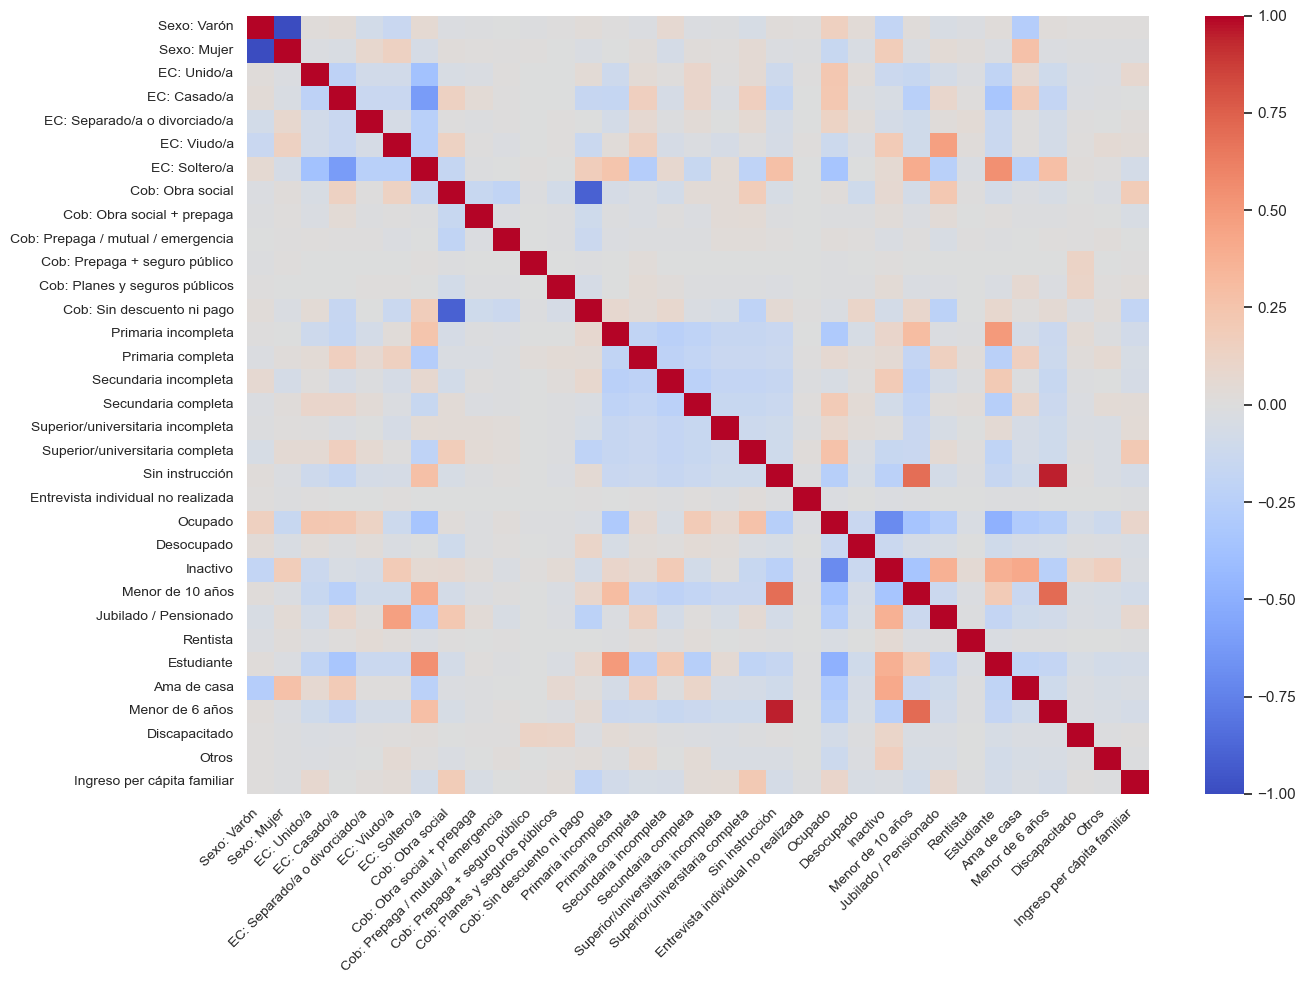

In [46]:
plt.figure(figsize=(14,10))

sns.heatmap(dummies.corr(), vmin=-1, vmax=1, cmap="coolwarm")

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [47]:
### Ejercicio 5

In [48]:
# 1. Contamos cuántas personas no respondieron (ESTADO == 0)
cantidad_no_respondieron = df[df['ESTADO'] == 0].shape[0]
print(f"Hay {cantidad_no_respondieron} personas que no respondieron su condición de actividad.")

# 2. Guardamos las observaciones que SÍ respondieron en una base distinta (ESTADO != 0)
respondieron = df[df['ESTADO'] != 0].copy()

# 3. Guardamos las observaciones que NO respondieron en otra base (ESTADO == 0)
norespondieron = df[df['ESTADO'] == 0].copy()

Hay 6 personas que no respondieron su condición de actividad.


In [49]:
# Ejercicio 6

In [50]:
ocupados = respondieron[respondieron['ESTADO'] == 1]

In [51]:
print(f"Cantidad de ocupados: {ocupados.shape[0]}")

Cantidad de ocupados: 3882


In [52]:
# Ejercicio 7

In [53]:
# Hacemos una copia para no modificar accidentalmente otras bases
ocupados = ocupados.copy()

# Reconstruimos la base regional completa con todas las columnas originales
# (df1 y df2 ya estaban filtradas por región)
base_completa = pd.concat([df1.copy(), df2.copy()], ignore_index=True)

# Traemos solo las variables que ahora necesitamos
vars_extra = ['CAT_OCUP', 'PP07H']

for var in vars_extra:
    if var in base_completa.columns:
        ocupados[var] = base_completa.loc[ocupados.index, var].values

# Pasemos a numérico las variables por si alguna vino como string
ocupados['CAT_OCUP'] = pd.to_numeric(ocupados['CAT_OCUP'], errors='coerce') #errors='coerce' simplemente hace que si hay alguna variable que no pueda transformar, la haga NaN
ocupados['PP07H']   = pd.to_numeric(ocupados['PP07H'], errors='coerce')

# De las correciones previas de los ejercicios, reemplazamos no respuesta por NaN
# Dado por los diccionarios sabemos que si CAT_OCUP = 9 o PP07H = 9 esto es equivalente a NaN.

ocupados['CAT_OCUP'] = ocupados['CAT_OCUP'].replace(9, np.nan)
ocupados['PP07H']    = ocupados['PP07H'].replace(9, np.nan)

# Creamos la variable informal según la consigna:
# 1 = informal
# 0 = formal
ocupados['informal'] = np.where(
    ((ocupados['CAT_OCUP'] == 3) & (ocupados['PP07H'] == 2)) |  # asalariado sin descuento jubilatorio
    (ocupados['CAT_OCUP'] == 4),                                # trabajador familiar sin remuneración
    1,
    0
)

# Chequeamos que todo este bien:
print(ocupados[['AÑO', 'CAT_OCUP', 'PP07H', 'informal']].head())
print(ocupados['informal'].value_counts(dropna=False))
print(pd.crosstab(ocupados['AÑO'], ocupados['informal'], normalize='index') * 100)

     AÑO  CAT_OCUP  PP07H  informal
3   2025       2.0    0.0         0
6   2025       3.0    2.0         1
7   2025       3.0    1.0         0
10  2025       3.0    1.0         0
11  2025       3.0    2.0         1
informal
0    2530
1    1352
Name: count, dtype: int64
informal          0          1
AÑO                           
2005      62.964989  37.035011
2025      67.137293  32.862707


In [54]:
### Ejercicio 8: 

In [55]:
ocupados.columns

Index(['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC',
       'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H',
       'PP07A', 'AÑO', 'CAT_OCUP', 'PP07H', 'informal'],
      dtype='object')

In [67]:
'EMPLEO' in ocupados.columns # Traigamos a la varaible empleo: if 'EMPLEO' in base_completa.columns: ocupados['EMPLEO'] = base_completa.loc[ocupados.index, 'EMPLEO'].values

False

In [68]:
# Quedemonos primero nos quedamso con el año 2025, que es aquel donde solo existe la variable EMPLEO (implementada en 2023)

# Filtramos únicamente el año 2025 (donde existe EMPLEO)
base_2025 = ocupados[ocupados['AÑO'] == 2025].copy()

In [69]:
# Ahora, transformemos a la variable EMPLEO de forma tal que este corregida como hemos hecho para otras variables, es decir lo que representa 9, 99, 9999, etc a lo que lo transformamos anteriormente

# Sabemos que por diccionario, la variable EMPLEO si toma valor 1 = formal, si toma valor 2 = informal, y por último si toma valor 9 = Ns/Nr
base_2025['informal_EMPLEO'] = np.nan

base_2025.loc[ocupados_2025['EMPLEO'] == 1, 'informal_EMPLEO'] = 0 # 0 = formal
base_2025.loc[ocupados_2025['EMPLEO'] == 2, 'informal_EMPLEO'] = 1 # 1 = informal

NameError: name 'ocupados_2025' is not defined

In [ ]:
# Nos quedamos solo con observaciones válidas en ambas variables
comparacion = base_2025[['informal', 'informal_EMPLEO']].dropna()

In [ ]:
# Calculamos coincidencias
iguales = (comparacion['informal'] == comparacion['informal_EMPLEO']).sum()
distintos = (comparacion['informal'] != comparacion['informal_EMPLEO']).sum()
total = len(comparacion)

print(f"Total de casos comparables: {total}")
print(f"Coinciden: {iguales} ({round(iguales/total*100,1)}%)")
print(f"No coinciden: {distintos} ({round(distintos/total*100,1)}%)")

In [ ]:
pd.crosstab(comparacion['informal'], comparacion['informal_EMPLEO'])

In [ ]:
### Ejercicio 9:

In [62]:
# Tabla: edad e ingreso promedio por año e informalidad
tabla = ocupados.groupby(['AÑO', 'informal']).agg({
    'CH06': 'mean',
    'IPCF': 'mean'
}).reset_index()

print(tabla)

    AÑO  informal       CH06           IPCF
0  2005         0  41.506516     484.261739
1  2005         1  35.703102     276.353160
2  2025         0  43.451051  490117.072893
3  2025         1  36.361481  311963.185393


In [64]:
tabla = ocupados.groupby(['AÑO', 'informal']).agg({
    'CH06': 'mean',        # edad
    'IPCF': 'mean',        # ingreso
    'NIVEL_ED': 'mean',    # educación
    'CH04': lambda x: (x==1).mean()  # proporción de varones
}).reset_index()

tabla = tabla.rename(columns={
    'CH06': 'edad_promedio',
    'IPCF': 'ingreso_promedio',
    'NIVEL_ED': 'educacion_promedio',
    'CH04': 'prop_varones'
})

print(tabla)

    AÑO  informal  edad_promedio  ingreso_promedio  educacion_promedio  \
0  2005         0      41.506516        484.261739            3.868810   
1  2005         1      35.703102        276.353160            3.129985   
2  2025         0      43.451051     490117.072893            4.359681   
3  2025         1      36.361481     311963.185393            3.776296   

   prop_varones  
0      0.643788  
1      0.463811  
2      0.561276  
3      0.508148  


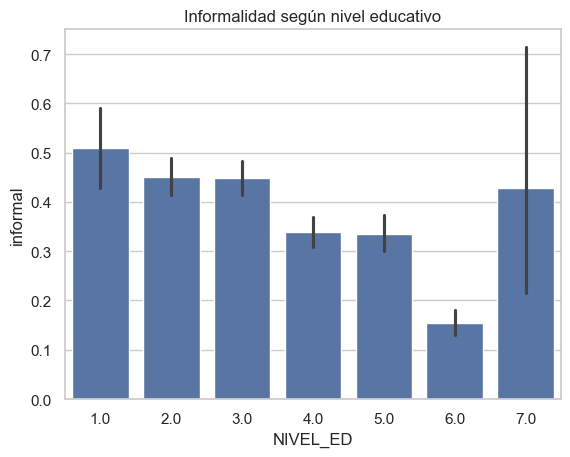

In [72]:
#Informalidad por nivel educativo
sns.barplot(data=ocupados, x='NIVEL_ED', y='informal')
plt.title('Informalidad según nivel educativo')
plt.savefig('grafico_educacion.png', dpi=300, bbox_inches='tight')
plt.show()

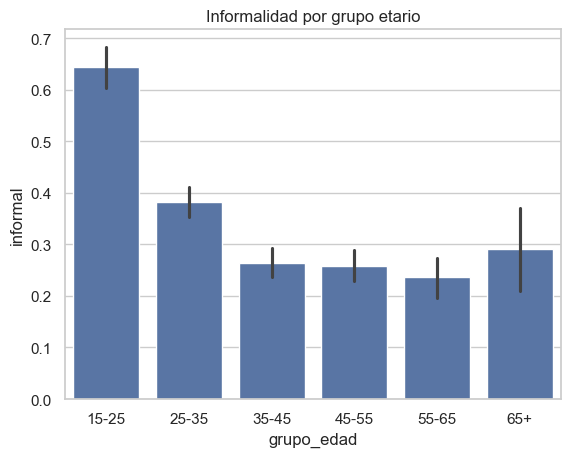

In [71]:
#informalidad por grupo etario
sns.barplot(data=ocupados, x='grupo_edad', y='informal')
plt.title('Informalidad por grupo etario')
plt.savefig('grafico_edad.png', dpi=300, bbox_inches='tight')
plt.show()